## Feature Scaling

In [ ]:
##types: Standardization || Normalization --these 2 main types.

In [15]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
## train_test_split is a scikit-learn class used to split data into 4 datasets.

In [4]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df2 = df[['survived','pclass','age','parch']]

In [8]:
df3 = df2.fillna(df2.mean())

In [16]:
X = df3.drop('survived', axis=1)
y = df3['survived']

print('shape of X:',X.shape)
print('shape of y:',y.shape)


shape of X: (891, 3)
shape of y: (891,)


In [21]:
from sklearn.model_selection import train_test_split


In [41]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.9, random_state=51)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(89, 3)
(802, 3)
(89,)
(802,)


In [ ]:
#standard scaler

In [42]:
sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [43]:
X_train_sc = sc.transform(X_train)
X_test_sc = sc.transform(X_test)

In [53]:
X_test_sc_df = pd.DataFrame(X_test_sc, columns = ['pclass','age','parch'])

In [52]:
X_train_sc_df = pd.DataFrame(X_train_sc, columns=['pclass','age','parch'])

In [55]:
X_train_sc_df.head()

,pclass,age,parch
0,-0.423507,-0.816485,-0.501652
1,0.792367,0.153785,-0.501652
2,0.792367,0.176774,-0.501652
3,0.792367,0.864415,5.222324
4,0.792367,1.781270,-0.501652


In [57]:
X_train_sc_df.describe().round(2)

,pclass,age,parch
count,89.00,89.00,89.00
mean,-0.00,0.00,-0.00
std,1.01,1.01,1.01
min,-1.64,-2.06,-0.50
25%,-0.42,-0.59,-0.50
50%,0.79,0.15,-0.50
75%,0.79,0.25,0.64
max,0.79,2.85,5.22


In [ ]:
#minmaxscaler

In [58]:
mms = MinMaxScaler()

In [60]:
mms.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[ 3.,65., 5.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[1. ,0.67,0. ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[ 2. ,64.33, 5. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['pclass','age','parch']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.5 ,-0.01, 0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,89


In [61]:
X_train_mms = mms.transform(X_train)

In [67]:
X_test_mms = mms.transform(X_test)

In [68]:
X_train_mms_df = pd.DataFrame(X_train_mms, columns = ['pclass','age','parch'])

In [69]:
X_test_mms_df = pd.DataFrame(X_test_mms, columns = ['pclass','age','parch'])

In [70]:
X_train_mms_df

,pclass,age,parch
0,0.5,0.253847,0.0
1,1.0,0.451253,0.0
2,1.0,0.455930,0.0
3,1.0,0.595834,1.0
4,1.0,0.782372,0.0
...,...,...,...
84,1.0,0.595834,0.0
85,1.0,0.451253,0.2
86,1.0,0.735738,0.6
87,1.0,0.451253,0.2


In [71]:
X_test_mms_df

,pclass,age,parch
0,0.0,0.611379,0.0
1,1.0,0.487020,0.0
2,1.0,0.455930,0.0
3,0.0,0.451253,0.0
4,0.5,0.518110,0.2
...,...,...,...
797,0.0,0.451253,0.0
798,1.0,0.300482,0.2
799,1.0,0.331572,0.0
800,1.0,0.533655,0.0


In [72]:
X_train_mms_df.describe()

,pclass,age,parch
count,89.000000,89.000000,89.000000
mean,0.674157,0.419965,0.087640
std,0.413557,0.204607,0.175694
min,0.000000,0.000000,0.000000
25%,0.500000,0.300482,0.000000
50%,1.000000,0.451253,0.000000
75%,1.000000,0.471475,0.200000
max,1.000000,1.000000,1.000000


In [ ]:
# to check whether distribution is done correctly, we can plot it using sns pairplot.

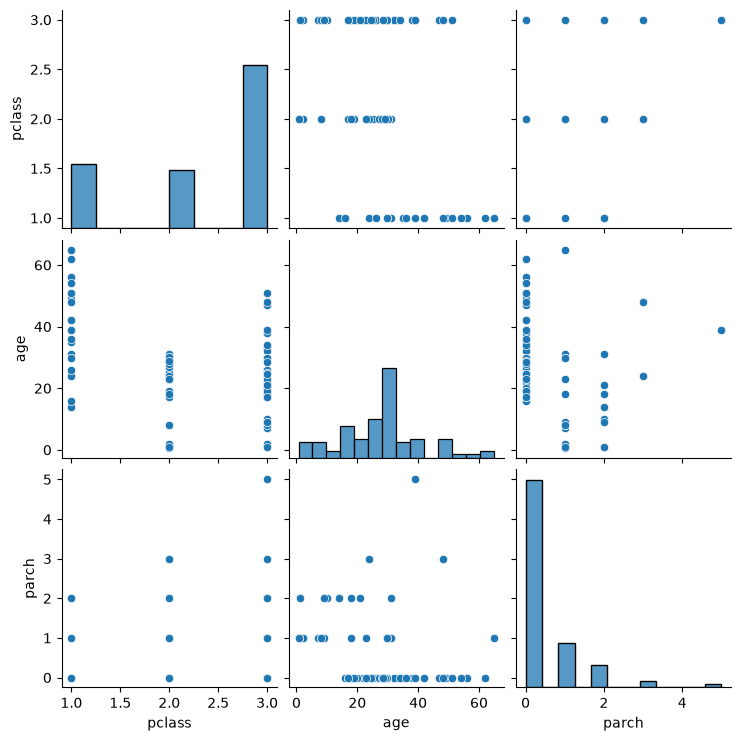

In [73]:
sns.pairplot(X_train)

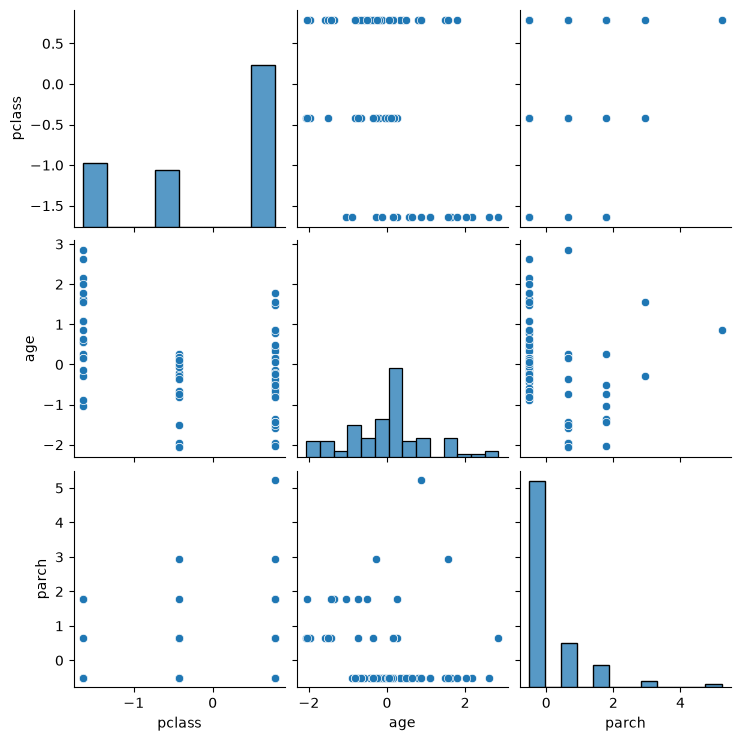

In [75]:
sns.pairplot(X_train_sc_df)

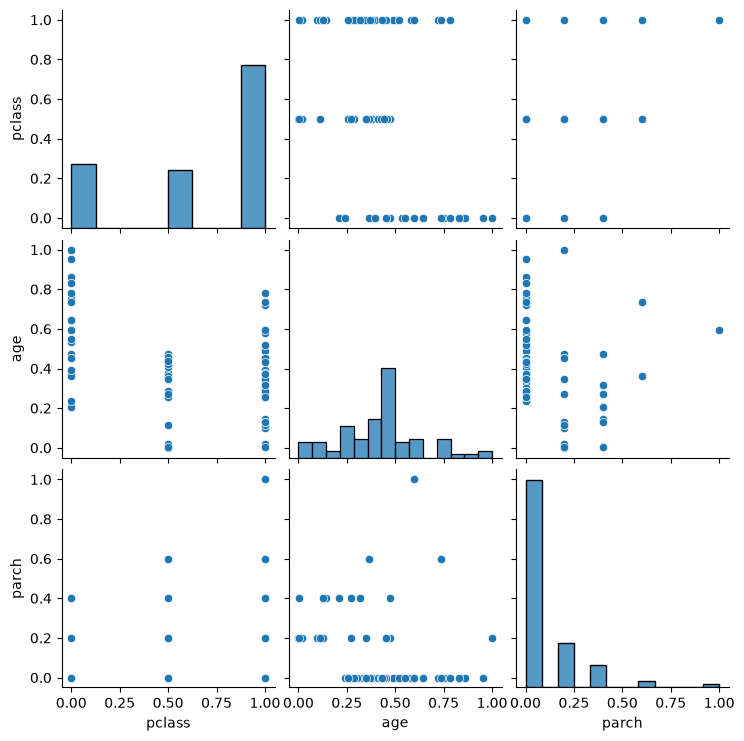

In [76]:
sns.pairplot(X_train_mms_df)